# Hallucination Detection Benchmark — Google Colab Runner

Runs the `benchmark/` pipeline (SelfCheckGPT vs RAG Verification vs LLM-as-a-Judge) on a Colab GPU, since it needs more RAM/VRAM than a typical local machine.

**Before running:** `Runtime -> Change runtime type -> T4 GPU` (or better).

Steps: (1) get the code onto Colab, (2) install dependencies, (3) run the benchmark, (4) view/download results.

In [ ]:
!nvidia-smi

Tue Aug  4 14:26:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1 — Get the code onto Colab

**Option A (recommended): upload a zip.** On your local machine, zip the `benchmark/` folder
(the one containing `main.py`, `config.py`, etc.) into `benchmark.zip`, then run the cell below and
pick that file.

If you already used Option A, skip the "Option B" cell further down.

In [ ]:
from google.colab import files

uploaded = files.upload()  # select your benchmark.zip in the dialog

Saving benchmark.zip to benchmark.zip


In [ ]:
import os
import zipfile

zip_name = list(uploaded.keys())[0]
print(f"Uploaded file: {zip_name} ({os.path.getsize(zip_name)} bytes)")

with zipfile.ZipFile(zip_name, "r") as z:
    names = z.namelist()
    print(f"Zip contains {len(names)} entries, e.g.: {names[:10]}")
    assert any(n.endswith("main.py") for n in names), (
        "This zip has no main.py in it — re-zip the 'benchmark' folder itself "
        "(the one with main.py/config.py inside it), not its parent or an unrelated folder."
    )
    # Windows' Compress-Archive writes backslashes as path separators, which zipfile
    # on Linux treats as literal filename characters instead of directories -
    # normalize them before extracting.
    for member in z.infolist():
        normalized = member.filename.replace("\\", "/")
        target = os.path.join("/content", normalized)
        if normalized.endswith("/"):
            os.makedirs(target, exist_ok=True)
            continue
        os.makedirs(os.path.dirname(target), exist_ok=True)
        with z.open(member) as src, open(target, "wb") as dst:
            dst.write(src.read())

print(os.listdir("/content"))

Uploaded file: benchmark.zip (33544 bytes)
Zip contains 24 entries, e.g.: ['benchmark\\config.py', 'benchmark\\Hallucination_Benchmark_Colab.ipynb', 'benchmark\\main.py', 'benchmark\\README.md', 'benchmark\\requirements.txt', 'benchmark\\analysis\\stats_analysis.py', 'benchmark\\analysis\\visualize.py', 'benchmark\\analysis\\__init__.py', 'benchmark\\data\\prepare_dataset.py', 'benchmark\\data\\__init__.py']
['.config', 'benchmark.zip', 'benchmark', 'sample_data']


**Option B: clone from a git repo instead of uploading a zip.** Only run this if you pushed the
`benchmark/` folder to your own GitHub repo, and skip Option A above. Edit `REPO_URL` first.

In [ ]:
REPO_URL = "https://github.com/<your-username>/<your-repo>.git"  # edit me
!git clone "$REPO_URL" /content/repo

In [ ]:
# Auto-locate main.py under /content instead of assuming a fixed path, since the
# zip/clone can extract with different top-level folder names (or no subfolder at all).
import os

matches = [root for root, _, fnames in os.walk("/content") if "main.py" in fnames and "config.py" in fnames]
assert matches, "Couldn't find main.py under /content — check that the upload/clone step above succeeded."
BENCHMARK_DIR = matches[0]
print(f"Found benchmark code at: {BENCHMARK_DIR}")
%cd $BENCHMARK_DIR

Found benchmark code at: /content/benchmark
/content/benchmark


## Step 2 — Install dependencies

This installs everything needed for `--mock`, `--lite`, and `--backend transformers` runs.
`vllm` is intentionally left out here (heavy install, only needed for `--backend vllm`) — see the
optional cell below if you want it.

`torch` is deliberately **not** reinstalled: Colab ships with a GPU-matched build preinstalled, and
`pip install torch` can silently replace it with a mismatched/CPU build and break GPU access.

In [ ]:
!pip install -q transformers sentence-transformers faiss-cpu datasets pandas scipy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 97.6 MB/s eta 0:00:00


In [ ]:
import torch

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU visible to torch - check Runtime > Change runtime type > GPU, "
          "then Runtime > Disconnect and delete runtime, then reconnect.")

torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Optional — only needed for `--backend vllm` with the full 8B paper-scale models. Slow install,
and the 8B models likely won't fit on a free T4 GPU (16GB VRAM). Prefer `--paper` (or `--lite`)
below unless you have a bigger GPU (e.g. Colab Pro A100).


In [ ]:
# !pip install -q vllm

## Step 3 — Run the benchmark

Pick one:
- `--mock`: fastest, no downloads, just sanity-checks the pipeline.
- `--lite` (smallest, works almost anywhere): tiny 0.5B models, for machines/GPUs with very little RAM/VRAM.
- `--paper` (recommended on a free T4): 1.5B generator + judge (sharing weights, no extra VRAM) and a
  small BGE embedder — sized to fit a free single-T4 Colab GPU while staying closer to paper scale.
- `--paper --strong-judge`: as above, plus a second judging pass with a 3B model, loaded only after
  the 1.5B generator/judge are freed (still fits a T4 since the models are never resident together).
- `--backend transformers` (no `--lite`/`--paper`): full paper-scale 8B models — needs a large-VRAM GPU
  (e.g. Colab Pro A100), not a free T4.

`--seed 42` (default) fixes the per-prompt generation seed (Methodology III-B): prompt *i* is
always generated from the same random state regardless of model scale, so `--lite` and `--paper`
runs stay prompt-aligned for a clean cross-scale F1 comparison. `--lite` and `--paper` below write
to separate `--output-dir`s (`results` / `results_paper`) so they don't overwrite each other.

In [ ]:
!python main.py --mock --total-prompts 40

In [ ]:
!python main.py --lite --total-prompts 100 --seed 42 --output-dir results

In [ ]:
!python main.py --paper --total-prompts 100 --seed 42 --output-dir results_paper

--paper: using Qwen/Qwen2.5-1.5B-Instruct / BAAI/bge-small-en-v1.5 on cuda
README.md: 100% 1.90k/1.90k [00:00<00:00, 2.85MB/s]

qa/train-00000-of-00001-a1fd1f8323203fa5(…): downloading bytes:  50% 1.89M/3.75M [00:01<00:00, 2.04MB/s, 10.0kB/s  ]
qa/train-00000-of-00001-a1fd1f8323203fa5(…): downloading bytes: 100% 3.75M/3.75M [00:01<00:00, 2.91MB/s,  364kB/s  ]
qa/train-00000-of-00001-a1fd1f8323203fa5(…): reconstructing file: 100% 3.75M/3.75M [00:01<00:00, 2.91MB/s,  365kB/s  ]
Generating train split: 100% 10000/10000 [00:00<00:00, 184258.10 examples/s]
README.md: 100% 9.59k/9.59k [00:00<00:00, 24.7MB/s]

generation/validation-00000-of-00001.par(…): downloading bytes:  82% 183k/223k [00:00<00:00, 250kB/s]
generation/validation-00000-of-00001.par(…): downloading bytes: 100% 222k/222k [00:00<00:00, 302kB/s, 21.9kB/s  ]
generation/validation-00000-of-00001.par(…): reconstructing file: 100% 223k/223k [00:00<00:00, 302kB/s, 21.9kB/s  ]
Generating validation split: 100% 817/817 [00:00<00:00, 1

In [ ]:
!python main.py --paper --strong-judge --total-prompts 100 --seed 42 --output-dir results_paper

--paper: using Qwen/Qwen2.5-1.5B-Instruct / BAAI/bge-small-en-v1.5 on cuda
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 338/338 [00:06<00:00, 52.74it/s]
Loading weights: 100% 199/199 [00:00<00:00, 5858.42it/s]
/content/benchmark/detectors/rag_verification_detector.py:44: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.embedding_dim = self.embedder.get_sentence_embedding_dimension()
[run_benchmark] batch_size=1 prompt 1/100 | elapsed 0.0 min | ETA 0.0 min
[run_benchmark] batch_size=1 prompt 2/100 | elapsed 0.4 min | ETA 17.5 min
[run_benchmark] batch_size=1 prompt 3/100 | elapsed 1.4 min | ETA 45.6 min
[run_benchmark] batch_size=1 prompt 4/100 | elapsed 2.3 min | ETA 55.0 min
[run_benchmark] batch_size=1 prompt 5/100 | elapsed 3.0 min | ETA 57.4 min
[run_benchmark] batch_size=1 prompt 6/100 | elapsed 3.9 min | ETA 60.9 min
[run_benchmark] batch_size=1 prompt 7/100 | elapsed 4.6 m

In [ ]:
# Full paper-scale run - only if your Colab GPU has enough VRAM for an 8B model.
# !python main.py --backend transformers --total-prompts 500 --seed 42 --output-dir results_full

## Step 4 — View and download results

In [ ]:
import os

import pandas as pd
from IPython.display import display

for out_dir in ["results", "results_paper"]:
    accuracy_path = f"{out_dir}/accuracy_metrics.csv"
    if os.path.exists(accuracy_path):
        print(out_dir)
        display(pd.read_csv(accuracy_path))

# Only present if you ran with --strong-judge
if os.path.exists("results_paper/strong_judge_accuracy_metrics.csv"):
    display(pd.read_csv("results_paper/strong_judge_accuracy_metrics.csv"))

results_paper


,paradigm,f1,precision,recall,n
0,llm_as_judge,0.216216,0.800000,0.125000,200
1,rag_verification,0.802548,0.677419,0.984375,200
2,selfcheckgpt,0.785276,0.646465,1.000000,200


,paradigm,f1,precision,recall,n
0,llm_as_judge_strong,0.782875,0.643216,1.0,200


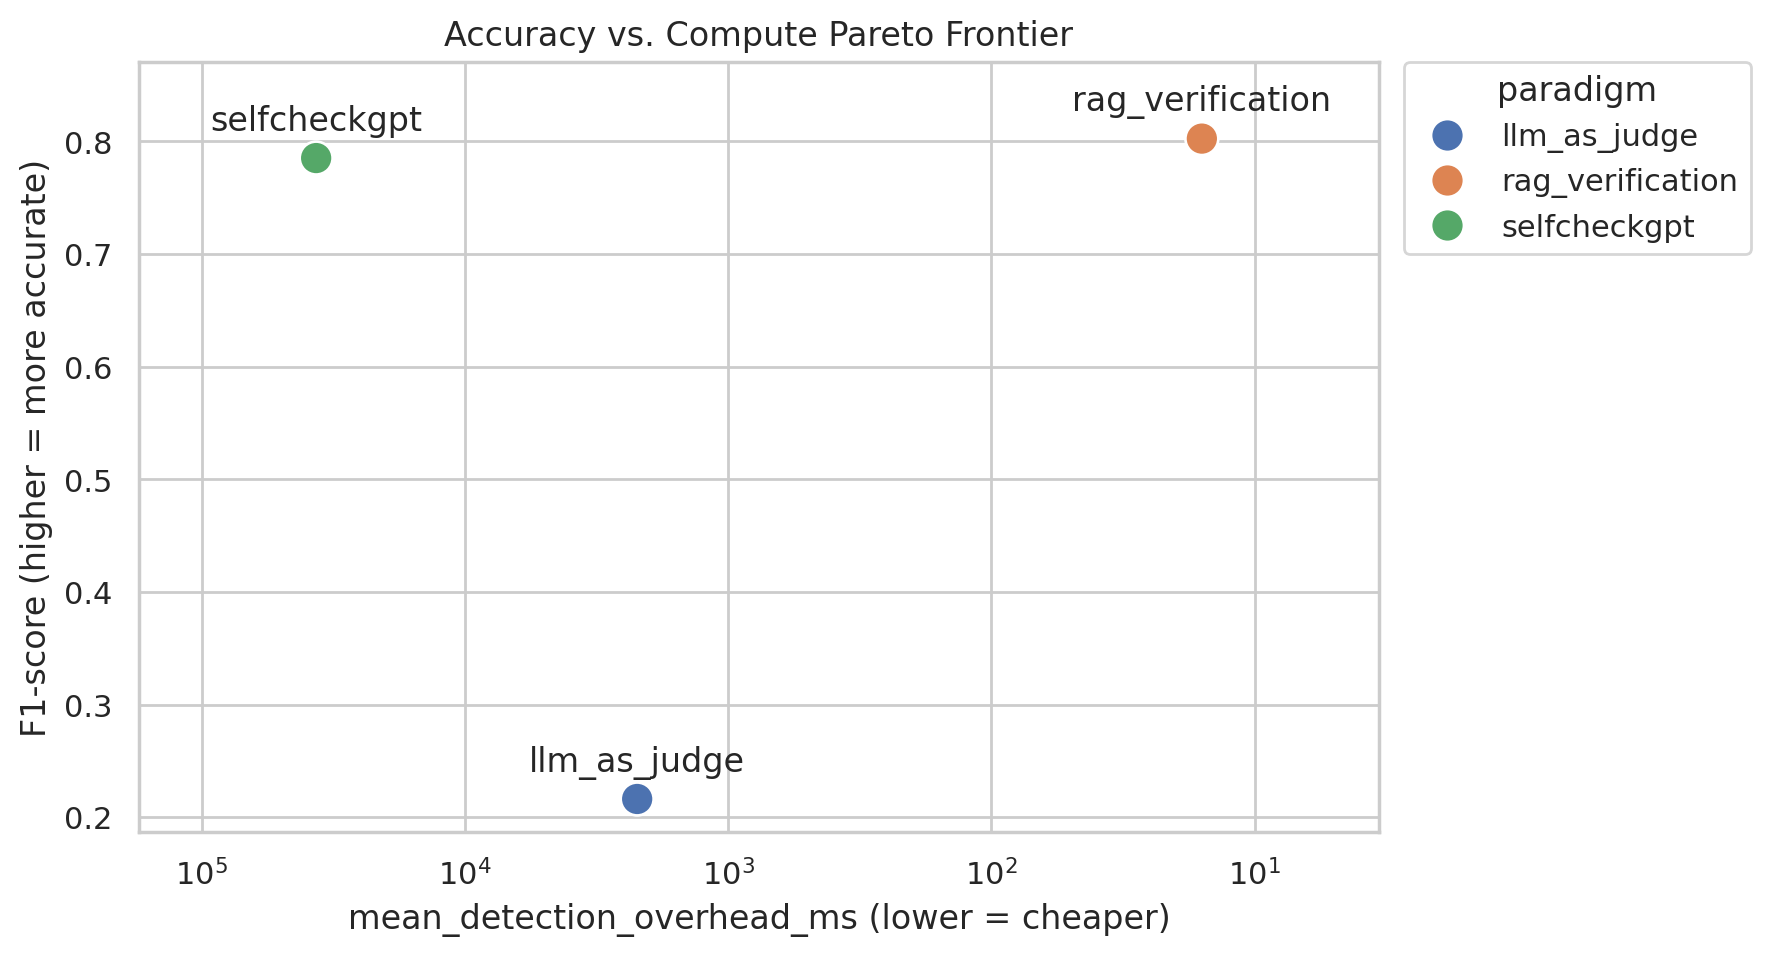

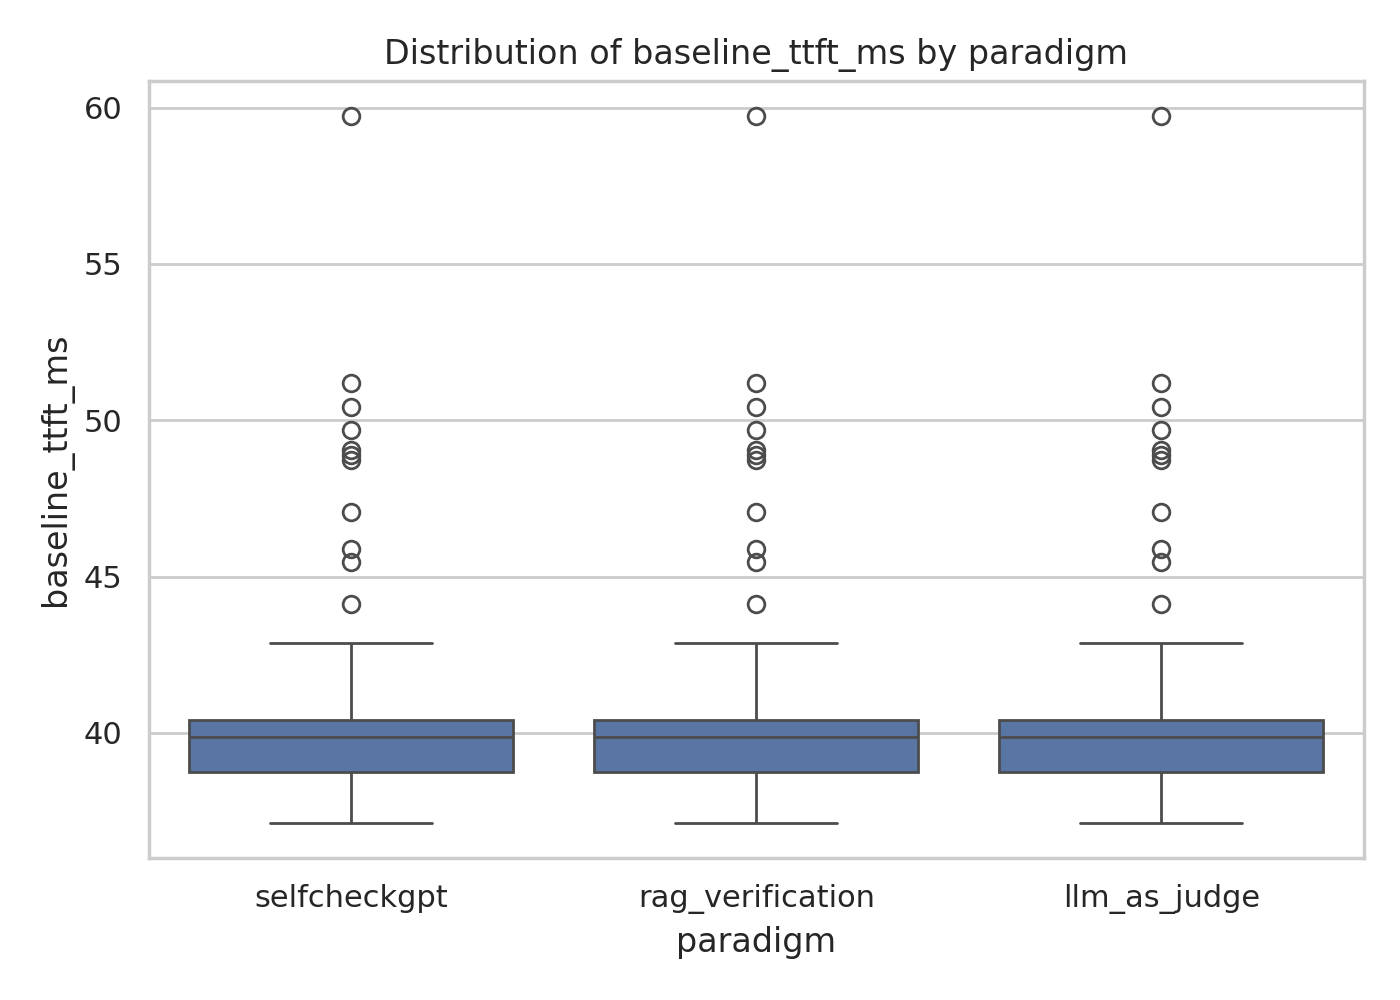

In [ ]:
import os

from IPython.display import Image, display

for out_dir in ["results", "results_paper"]:
    for plot in ["pareto_frontier.png", "ttft_distribution.png"]:
        path = f"{out_dir}/plots/{plot}"
        if os.path.exists(path):
            display(Image(path))

In [ ]:
import os
import shutil

from google.colab import files

for out_dir in ["results", "results_paper"]:
    if os.path.isdir(out_dir):
        shutil.make_archive(f"/content/{out_dir}", "zip", out_dir)
        files.download(f"/content/{out_dir}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>